## Pre-MCMC calculations

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import astropy
import scipy.integrate as integrate
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
from IPython.display import display, Math
from scipy.optimize import root_scalar as rs
from tqdm import tqdm
import os

In [86]:
# Importing constants 

Planck = astropy.cosmology.realizations.Planck18

T_CMB = Planck.Tcmb0  # Temperature of the CMB
H_0 = Planck.H0  # Current Hubble constant
Omega_m = Planck.Om0  # Matter density parameter
Omega_lambda = Planck.Ode0  # Dark energy density parameter
c = astropy.constants.c.to('km/s')  # Speed of light in km/s
sigma_T = astropy.constants.sigma_T.to('km2')  # Thomson scattering cross-section in km^2
Omega_b = Planck.Ob0  # Baryon density parameter
h = Planck.h  # Dimensionless Hubble parameter
rho_crit_0 = Planck.critical_density0.to('kg/m3')  # Critical density of the universe at z = 0 in kg/m^3


# Setting parameters

z = 8  # Redshift of the quasar bubbles 
f_H = 0.1  # fraction of neutral hydrogen at z = 8 (default 0.21)
k = 2.75

In [ ]:
# Input Data

data = pd.read_csv('Data/u_0.0pc_noise.csv')
root = pd.read_csv('root_vals_red(n_H = 1.38e11).csv')  # Root values for n_H = 1.38e11 km-3

Ang_deg = np.array(data['radius_y'])  # In arcmins
amp = np.array(data['amp_y']) * 1e-6  # Amplitude in K

In [88]:
# Importing the Flat Lambda CDM model

cosmo = FlatLambdaCDM(H0=H_0.value, Om0=Omega_m, Tcmb0= T_CMB.value)


# Obtaining the angular diameter distance at z

D_A = cosmo.angular_diameter_distance(z)  # units: Mpc/radian


# Defining a function that converts from our angular distance to proper distance

def AngToDist(Ang_deg= Ang_deg):
    
    Ang_rad = Ang_deg * np.pi / (180 * 60)  # Convert arcmins to radians
    Distance = D_A * Ang_rad  # Convert angular distance to actual distance

    return Distance  # in Mpc


In [89]:
# Calculating the actual transverse radii of the bubbles and y

R_T = AngToDist(Ang_deg)  # in Mpc

R_T = R_T.to('km')  # Convert to km

y = amp / T_CMB.value  

We will be using the following formula to calculate $n_e$ from $y$: 

$$ y = n_e \frac{\sigma_T}{3} \cdot \frac{0.001}{\sqrt{1 + z}} \cdot 2R_L $$

where $n_e$ is the **physical** number density of free electrons. And so the physical $n_H$ is:

$$ n_H = \frac{n_e}{1 - f_H} $$

Alternative formula to calculate the physical $n_H$: 

$$ \bar{n}_H = \frac{\rho_{crit}}{m_H} \cdot (1 - Y) \Omega_b \cdot (1 + z)^3 $$

where $ \rho_{crit} = \frac{3 H_0^2}{8 \pi G} $ and $ Y = 0.247 $ for our case.

and so $R_L$ is given by: 

$$ R_L = \frac{3 \cdot y \cdot \sqrt{1 + z}}{n_e \cdot \sigma_T \cdot 0.001 \cdot 2} $$

In this scenario, we divide $R_L$ by $k$ to simulate an extra factor in the $v_{rms}$ term 

$$ \Rightarrow R_L = \frac{1}{k} \cdot \frac{3 \cdot y \cdot \sqrt{1 + z}}{n_e \cdot \sigma_T \cdot 0.001 \cdot 2} $$

In [90]:
# Calculating n_H from cosmology

n_H = rho_crit_0/(astropy.constants.m_p) * (1 - 0.247) * (Omega_b) * (1 + z)**3 * np.array([1])
n_H = n_H.to('km-3')  # Convert to km^-3

# Calculating R_L through here: 

n_e = n_H * (1 - f_H)  
R_L = (3 * y * np.sqrt(1 + z)) / (sigma_T * n_e * 0.001 * 2)  # in km
R_L = R_L/k
R_L

<Quantity [4.96187677e+20, 5.52915439e+20, 5.27448275e+20, 4.92701022e+20,
           5.03335935e+20, 5.10165642e+20, 4.24990841e+20, 5.58262901e+20] km>

In [91]:
R_T/R_L

<Quantity [0.66179832, 0.62689386, 0.67445638, 0.72202175, 0.72488847,
           0.75094342, 0.92290717, 0.7189241 ]>

In [92]:
n_H

<Quantity [1.38195338e+11] 1 / km3>

## The Plan

We have the following formulae: 

$$ R(t) = \left( \frac{3 \cdot \dot{N} \cdot t}{4 \pi n_H} \right)^{1/3} \quad \quad , \quad \quad  t = t_Q - \frac{R(t)}{c} (1 - \cos \phi) \quad \quad , \quad \quad y = n_e \frac{\sigma_T}{3} \cdot \frac{0.001}{\sqrt{1 + z}} \cdot 2R_L $$

Now, in the longitudinal direction, $ \phi = 0 \Rightarrow \cos \phi = 1 \Rightarrow t = t_Q $

$$ \Rightarrow R_L(t) = \left( \frac{3 \cdot \dot{N} \cdot t_Q}{4 \pi n_H} \right)^{1/3} $$

Here, $R_L$ is obtained using $y$ and $n_e$ that are obtained from the simulation and from theory respectively. And so, we perform MCMC sampling on this equation to get an estimate for $\dot{N}$ and $t_Q$

For each sample of $(\dot{N}, t_Q)$, we solve for the following transverse equation ($\cos \phi = 0$) 

$$ t = t_Q - \frac{R_T(t)}{c} \Rightarrow t + \frac{R_T(t)}{c} - t_Q = 0 $$

$$ \Rightarrow t + \frac{1}{c} \left( \frac{3 \cdot \dot{N} \cdot t}{4 \pi n_H} \right)^{1/3}  - t_Q = 0 $$

we solve this equation numerically and obtain a $t$ which satisfies it. Using this, we calculate $R_T(t)$ and plug it back to the MCMC sampling which compares this with the value of $R_T(t)$ which is obtained from the simulation to calculate its joint likelihood function. 

This should give us the best fit $(\dot{N}, t_Q)$ and break their degeneracy



----

Now say, 

$$\tilde{\dot{N}} = {\dot{N}}/{10^{58}},  \tilde{t_Q} = t_Q/10^{7}$$  

then, 

$$ R = \left( \frac{3}{4 \pi n_H}\right)^{1/3} (\tilde{\dot{N}} \tilde{t_Q})^{1/3} \cdot (10^{58})^{1/3} \cdot (10^7 \cdot 3.156 \times 10^7)^{1/3} $$

The last $3.156 \times 10^7$ is for converting years into seconds

In [95]:
# Defining the model for calculating R(t) for a given N_dot, t_Q and n_H 

def radius_calc(theta, n_H): 
    N_tilde, t_tilde = theta
    return (((3)/(4*np.pi*n_H))**(1/3)) * (N_tilde * t_tilde)**(1/3) * (1e58)**(1/3) * (1e7 * 3.156e7)**(1/3)  # in km


# Defining the root finding function

def root_func(t, theta, n_H, c = c):
    N_tilde, t_tilde = theta
    N_dot = N_tilde * 1e58  # in s^-1
    t_Q = t_tilde * 1e7 * 3.156e7  # in seconds

    return (t * 1e7 * 3.156e7) + (radius_calc([N_tilde, t], n_H).value)/(c.value) - t_Q

In [96]:
# For faster processing, we create a 2D grid for root finding results
# based on the imported root finding results

# Unique values of N_tilde and t_Q from the imported root results
N_list = np.array(sorted(root['N_tilde'].unique()))
t_list = np.array(sorted(root['t_Q'].unique()))

# Creating a 2D grid to store root values (easier to look up)
root_grid = np.zeros((len(N_list), len(t_list)))
for index, row in root.iterrows():
    i = np.where(N_list == row['N_tilde'])[0][0]
    j = np.where(t_list == row['t_Q'])[0][0]
    root_grid[i, j] = row['root']

# A function that returns the root for given N_tilde and t_tilde
def root_find(theta):
    N_tilde, t_tilde = theta
    i = np.argmin(np.abs(N_list - N_tilde))
    j = np.argmin(np.abs(t_list - t_tilde))
    return root_grid[i, j]


In [97]:
# Calculating error in the diameter

Ang_err = np.array([0.5] * len(Ang_deg))  # Error in determining the angular diameter in arcmins
Radius_err = (Ang_err * np.pi / (180 * 60) * D_A).to('km') # Convert angular error to actual diameter error
y_err = np.array([0.1e-6] * len(y))  # Error in y parameter

In [98]:
N_min = 0
N_max = 20

t_min = 0
t_max = 20

In [120]:
# Defining the log-likelihood function

def lnlike(theta, x, y_obs, y_err, R_T_obs, R_err):
    R_L_model = radius_calc(theta, x)   # calculating the model R_L for the sample theta
    y_model = R_L_model * k * (sigma_T * n_e * 0.001 * 2) / (3 * np.sqrt(1 + z))

    # t = root_find(theta)   # finding the root for t
    t = rs(root_func, args=(theta, n_H), bracket=[1e-40, 1e40]).root 
    R_T_model = radius_calc([theta[0], t], x)   # calculating the model R_T for the sample Ndot and t

    return -0.5 * np.sum(((R_T_model - R_T_obs) / R_err) ** 2 + ((y_obs - y_model) / y_err) ** 2 )   # joint likelihood for R_L and R_T

# Defining the log-prior function

def lnprior(theta):
    N_tilde, t_tilde = theta
    if N_tilde < N_min or t_tilde < t_min or N_tilde > N_max  or t_tilde > t_max:
        return -np.inf
    return 0.0

# Defining the log-posterior function

def lnprob(theta, n_H, y_obs, y_err, R_T_obs, R_err):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, n_H, y_obs, y_err, R_T_obs, R_err)


# Grid Based calculations

We create a grid for the two parameters and calculate the log-probability for each point in this grid, using which we can determine the individual posteriors. 

The values in the grid go from $$ \tilde{N}: 0 \rightarrow N_{max} \ \\\ \tilde{t}: 0 \rightarrow t_{max}$$

In [ ]:
# Creating a list for N_tilde and t_tilde

N_tilde_list = np.arange(0.1, N_max, 0.01)  # 0.01 step size
t_tilde_list = np.arange(0.1, t_max, 0.01)  # 0.01 step size
r = 0

# Calculating the log probability over the grid and 
# storing it in a 2D array

logp_grid = np.zeros((len(N_tilde_list), len(t_tilde_list)))

for i in tqdm(range(len(N_tilde_list))): 
    for j in range(len(t_tilde_list)):
        theta = [N_tilde_list[i], t_tilde_list[j]]
        logp_grid[i, j] = lnprob(theta, n_H, y[r], y_err[r], R_T[r], Radius_err[r]) 


# Converting to probabilities
max_logp = np.max(logp_grid)
p_grid = np.exp(logp_grid - max_logp)
p_grid /= np.sum(p_grid)  # Normalizing

100%|██████████| 199/199 [01:06<00:00,  3.00it/s]


In [211]:
# Calculating the individual marginalized distributions
p_N_tilde = np.sum(p_grid, axis=1)  # Marginalized over t_tilde
p_t_tilde = np.sum(p_grid, axis=0)  # Marginalized over N_tilde

# Calculating the cumulative distribution functions 

cdf_N_tilde = np.cumsum(p_N_tilde)
cdf_t_tilde = np.cumsum(p_t_tilde)

# Defining a function to calculate the quantiles
def quantile(cdf, values, q):
    index = np.searchsorted(cdf, q)
    if index >= len(values): 
        index = len(values) - 1
    return values[index]

# Calculating median and 1-sigma intervals for N_tilde and t_tilde

N_tilde_median = quantile(cdf_N_tilde, N_tilde_list, 0.5)
N_tilde_lower = quantile(cdf_N_tilde, N_tilde_list, 0.16)
N_tilde_upper = quantile(cdf_N_tilde, N_tilde_list, 0.84)

t_tilde_median = quantile(cdf_t_tilde, t_tilde_list, 0.5)
t_tilde_lower = quantile(cdf_t_tilde, t_tilde_list, 0.16)
t_tilde_upper = quantile(cdf_t_tilde, t_tilde_list, 0.84)

print(f"N_tilde: {N_tilde_median:.2f} (+{N_tilde_upper - N_tilde_median:.2f}/-{N_tilde_median - N_tilde_lower:.2f})")
print(f"t_tilde: {t_tilde_median:.2f} (+{t_tilde_upper - t_tilde_median:.2f}/-{t_tilde_median - t_tilde_lower:.2f})")

N_tilde: 4.60 (+0.80/-0.80)
t_tilde: 4.90 (+0.30/-0.30)


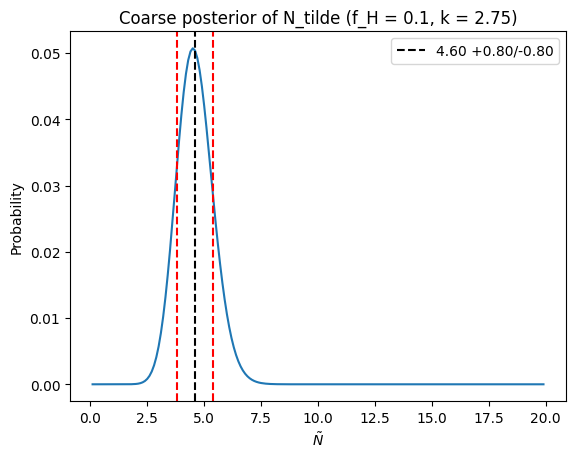

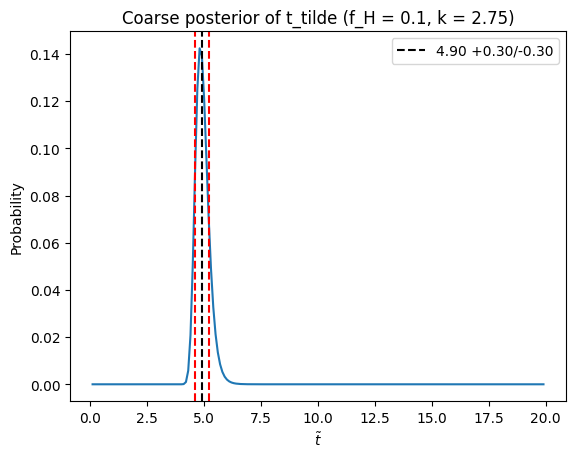

In [ ]:
# Creating output directories

os.makedirs(f'Output/Coarse', exist_ok=True)

# Plotting the posteriors 

plt.plot(N_tilde_list, p_N_tilde)
plt.axvline(N_tilde_median, color='black', linestyle='--', linewidth=1.5, label=f"{N_tilde_median:.2f} +{N_tilde_upper - N_tilde_median:.2f}/-{N_tilde_median - N_tilde_lower:.2f}")
plt.axvline(N_tilde_lower, color='red', linestyle='--', linewidth=1.5)
plt.axvline(N_tilde_upper, color='red', linestyle='--', linewidth=1.5)
plt.xlabel(r'$\tilde{N}$')
plt.ylabel('Probability')
plt.legend()
plt.title(f'Coarse posterior of N_tilde (f_H = {f_H}, k = {k})')
plt.savefig(f'Output/Coarse/N_tilde_{r}.png')
plt.show()

plt.plot(t_tilde_list, p_t_tilde)
plt.axvline(t_tilde_median, color='black', linestyle='--', linewidth=1.5, label=f"{t_tilde_median:.2f} +{t_tilde_upper - t_tilde_median:.2f}/-{t_tilde_median - t_tilde_lower:.2f}")
plt.axvline(t_tilde_lower, color='red', linestyle='--', linewidth=1.5)
plt.axvline(t_tilde_upper, color='red', linestyle='--', linewidth=1.5)
plt.xlabel(r'$\tilde{t}$')
plt.ylabel('Probability')
plt.legend()
plt.title(f'Coarse posterior of t_tilde (f_H = {f_H}, k = {k})')
plt.savefig(f'Output/Coarse/t_tilde_{r}.png')
plt.show()

##### Refined grid method

In [213]:
# Next, we refine the grid around the median values

# Define the refined range to be +/- 1 from lower/upper boundaries
N_tilde_ref_min = max(0.1, N_tilde_lower - 1)
N_tilde_ref_max = min(N_max, N_tilde_upper + 1)
t_tilde_ref_min = max(0.1, t_tilde_lower - 1)
t_tilde_ref_max = min(t_max, t_tilde_upper + 1)

N_tilde_list_ref = np.arange(N_tilde_ref_min, N_tilde_ref_max + 0.01, 0.01)  # 0.01 step size
t_tilde_list_ref = np.arange(t_tilde_ref_min, t_tilde_ref_max + 0.01, 0.01)  # 0.01 step size

# Calculating log probabilities on the refined grid
logp_grid_ref = np.zeros((len(N_tilde_list_ref), len(t_tilde_list_ref)))

for i in tqdm(range(len(N_tilde_list_ref))): 
    for j in range(len(t_tilde_list_ref)):
        theta = [N_tilde_list_ref[i], t_tilde_list_ref[j]]
        logp_grid_ref[i, j] = lnprob(theta, n_H, y[r], y_err[r], R_T[r], Radius_err[r])

# Converting to probabilities
max_logp_ref = np.max(logp_grid_ref)
p_grid_ref = np.exp(logp_grid_ref - max_logp_ref)
p_grid_ref /= np.sum(p_grid_ref)  # Normalizing

100%|██████████| 361/361 [02:54<00:00,  2.06it/s]


In [214]:
# Calculating the individual marginalized distributions
p_N_tilde_ref = np.sum(p_grid_ref, axis=1)   # Marginalized over t_tilde
p_t_tilde_ref = np.sum(p_grid_ref, axis=0)   # Marginalized over N_tilde

# Calculating the cumulative distribution functions
cdf_N_tilde_ref = np.cumsum(p_N_tilde_ref)
cdf_t_tilde_ref = np.cumsum(p_t_tilde_ref)

# Calculating median and 1-sigma intervals for N_tilde and t_tilde

N_tilde_median_ref = quantile(cdf_N_tilde_ref, N_tilde_list_ref, 0.5)
N_tilde_lower_ref = quantile(cdf_N_tilde_ref, N_tilde_list_ref, 0.16)
N_tilde_upper_ref = quantile(cdf_N_tilde_ref, N_tilde_list_ref, 0.84)

t_tilde_median_ref = quantile(cdf_t_tilde_ref, t_tilde_list_ref, 0.5)
t_tilde_lower_ref = quantile(cdf_t_tilde_ref, t_tilde_list_ref, 0.16)
t_tilde_upper_ref = quantile(cdf_t_tilde_ref, t_tilde_list_ref, 0.84)

print(f"N_tilde: {N_tilde_median_ref:.2f} (+{N_tilde_upper_ref - N_tilde_median_ref:.2f}/-{N_tilde_median_ref - N_tilde_lower_ref:.2f})")
print(f"t_tilde: {t_tilde_median_ref:.2f} (+{t_tilde_upper_ref - t_tilde_median_ref:.2f}/-{t_tilde_median_ref - t_tilde_lower_ref:.2f})")

N_tilde: 4.56 (+0.78/-0.73)
t_tilde: 4.90 (+0.31/-0.25)


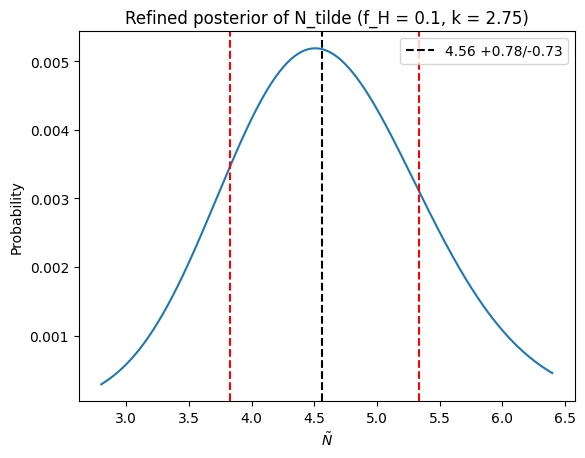

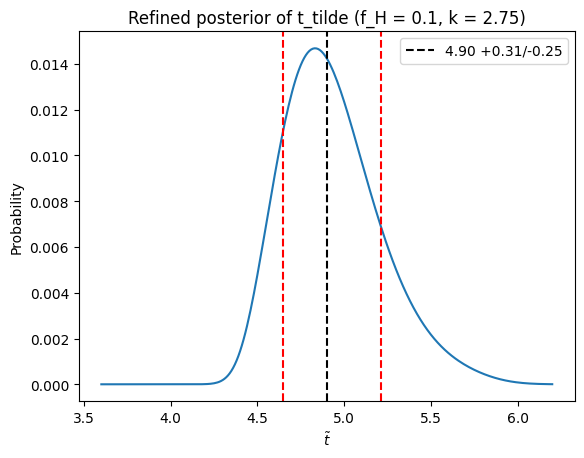

In [215]:
# Plotting the posteriors 

plt.plot(N_tilde_list_ref, p_N_tilde_ref)
plt.axvline(N_tilde_median_ref, color='black', linestyle='--', linewidth=1.5, label=f"{N_tilde_median_ref:.2f} +{N_tilde_upper_ref - N_tilde_median_ref:.2f}/-{N_tilde_median_ref - N_tilde_lower_ref:.2f}")
plt.axvline(N_tilde_lower_ref, color='red', linestyle='--', linewidth=1.5)
plt.axvline(N_tilde_upper_ref, color='red', linestyle='--', linewidth=1.5)
plt.xlabel(r'$\tilde{N}$')
plt.ylabel('Probability')
plt.legend()
plt.title(f'Refined posterior of N_tilde (f_H = {f_H}, k = {k})')
plt.savefig(f'Output/Refined/N_tilde_{r}.png')
plt.show()


plt.plot(t_tilde_list_ref, p_t_tilde_ref)
plt.axvline(t_tilde_median_ref, color='black', linestyle='--', linewidth=1.5, label=f"{t_tilde_median_ref:.2f} +{t_tilde_upper_ref - t_tilde_median_ref:.2f}/-{t_tilde_median_ref - t_tilde_lower_ref:.2f}")
plt.axvline(t_tilde_lower_ref, color='red', linestyle='--', linewidth=1.5)
plt.axvline(t_tilde_upper_ref, color='red', linestyle='--', linewidth=1.5)
plt.xlabel(r'$\tilde{t}$')
plt.ylabel('Probability')
plt.legend()
plt.title(f'Refined posterior of t_tilde (f_H = {f_H}, k = {k})')
plt.savefig(f'Output/Refined/t_tilde_{r}.png')
plt.show()